# EDA template

**Copy this file to `eda-<yourname>.ipynb` before you start working in it.**
One notebook per person — merging two people's edits to the same `.ipynb`
means resolving conflicts in JSON with embedded outputs.

Clear outputs before committing.

## Setup

Paths come from the package, not from relative `../data/...` strings, so every
cell works no matter which directory the kernel was started in.

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from un_general_debate_analysis.preprocessing import (
    OUT_DIR,
    META_COLUMNS,
    merge_country_year,
    sentence_count_columns,
)
from un_general_debate_analysis.lexicons import LEXICONS

# speeches_features.csv is 56 columns wide
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print(f"reading from {OUT_DIR}")
print(f"lexicons: {list(LEXICONS)}")

reading from /Users/b/Docs/UVA/FUDS/assignments/UN-General-Debate-Analysis/data/processed
lexicons: ['theme_trust', 'theme_transformation', 'theme_multilateralism', 'education', 'technology']


## Load the data

`features` is the main table: one row per speech (= one country-year), with
metadata, text statistics, VADER sentiment, and four columns per lexicon.

`terms` is long — one row per (year, lexicon, term) — and shows *which* words
drive a trend.

In [2]:
features = pd.read_csv(OUT_DIR / "speeches_features.csv")
terms = pd.read_csv(OUT_DIR / "lexicon_terms_by_year.csv")

print(f"features: {features.shape[0]:,} speeches x {features.shape[1]} columns")
print(f"terms:    {terms.shape[0]:,} rows")
print(f"years:    {features['year'].min()}-{features['year'].max()}")

# Sanity check: the full corpus is ~11k speeches. Many fewer means someone ran
# the pipeline with --limit; re-run it without one.
if len(features) < 10_000:
    print(f"\nWARNING: only {len(features):,} speeches — looks like a --limit sample.")

features: 11,141 speeches x 46 columns
terms:    5,046 rows
years:    1946-2025


In [3]:
features.head()

,country_code,country,year,session,region_name,sub_region_name,speaker_name,speaker_post,speaker_role,n_sentences,n_words,n_unique_lemmas,lexical_density,mean_sentence_length,sentiment_compound_mean,share_positive_sentences,share_negative_sentences,n_positive_sentences,n_negative_sentences,theme_trust_count,theme_trust_positive_sentences,theme_trust_negative_sentences,theme_trust_sentences,theme_transformation_count,theme_transformation_positive_sentences,theme_transformation_negative_sentences,theme_transformation_sentences,theme_multilateralism_count,theme_multilateralism_positive_sentences,theme_multilateralism_negative_sentences,theme_multilateralism_sentences,education_count,education_positive_sentences,education_negative_sentences,education_sentences,technology_count,technology_positive_sentences,technology_negative_sentences,technology_sentences,technology,technology_sentiment,education,education_sentiment,technology_education,technology_education_sentiment,term_counts
0,ARG,Argentina,1946,1,Americas,Latin America and the Caribbean,Mr. Arce,NaN,unknown,127,3305,943,0.485023,26.023622,0.260215,0.590551,0.204724,75,26,1,1,0,1,0,0,0,0,17,6,2,13,1,1,0,1,0,0,0,0,0,0.0000,1,0.8720,0,0.0,"{""charter"": 11, ""education"": 1, ""good faith"": ..."
1,AUS,Australia,1946,1,Oceania,Australia and New Zealand,Mr. Makin,NaN,unknown,125,4475,911,0.495866,35.800000,0.392232,0.720000,0.136000,90,17,4,4,0,4,0,0,0,0,51,29,7,39,0,0,0,0,1,1,0,1,1,0.6249,0,0.0000,0,0.0,"{""charter"": 28, ""cloud"": 1, ""confidence"": 1, ""..."
2,BEL,Belgium,1946,1,Europe,Western Europe,Mr. Van Langenhove,NaN,unknown,98,2479,688,0.482453,25.295918,0.229380,0.581633,0.214286,57,21,0,0,0,0,1,1,0,1,24,18,2,20,0,0,0,0,2,2,0,2,1,0.7068,0,0.0000,0,0.0,"{""charter"": 15, ""commerce"": 1, ""innovation"": 1..."
3,BLR,Belarus,1946,1,Europe,Eastern Europe,Mr. Kiselev,NaN,unknown,98,3011,803,0.521089,30.724490,0.233941,0.622449,0.295918,61,29,3,3,0,3,0,0,0,0,32,25,1,28,0,0,0,0,1,0,0,1,1,0.0000,0,0.0000,0,0.0,"{""charter"": 15, ""confidence"": 1, ""internationa..."
4,BOL,Bolivia (Plurinational State of),1946,1,Americas,Latin America and the Caribbean,Mr. Costa du Rels,NaN,unknown,55,1445,545,0.480969,26.272727,0.251342,0.563636,0.181818,31,10,1,1,0,1,0,0,0,0,3,2,0,3,1,1,0,1,0,0,0,0,0,0.0000,1,0.8126,0,0.0,"{""charter"": 2, ""confidence"": 1, ""security coun..."


### The text, loaded separately

`speeches_text.csv.gz` holds the cleaned text and the lemmatised, stop-word-free
tokens of every speech. It is a few hundred MB in memory for the full corpus, so
only load it when you actually need it (TF-IDF, topic models, word clouds).

In [4]:
texts = pd.read_csv(OUT_DIR / "speeches_text.csv.gz")
texts.head()

,country_code,year,text_clean,tokens_clean
0,ARG,1946,At the resumption of the first session of the ...,resumption first argentine wish state view num...
1,AUS,1946,The General Assembly of the United Nations is ...,meeting time hospitable city new york exercise...
2,BEL,1946,The principal organs of the United Nations hav...,principal organ functioning nearly nine month ...
3,BLR,1946,As more than a year has elapsed since the Unit...,year elapse since charter sign san francisco c...
4,BOL,1946,Coming to this platform where so many distingu...,coming platform many eloquent speaker precede ...


### `term_counts` is a JSON string

Parse it with `json.loads` (not `ast.literal_eval`) to get the per-term counts
for a single speech.

In [6]:
example = features.iloc[0]
print(f"{example['country']}, {example['year']}")
json.loads(example["term_counts"])

Argentina, 1946


{'charter': 11,
 'education': 1,
 'good faith': 1,
 'international law': 3,
 'multilateral': 1,
 'security council': 1,
 'solidarity': 1}

## Normalise before comparing

Speech length varies enormously across the corpus, and so does the number of
countries speaking each year (~50 in 1946, ~190 today). Raw counts are not
comparable across speeches or across years — always divide first.

- word counts (`<lexicon>_count`) by `n_words`
- sentence counts (`<lexicon>_sentences`) by `n_sentences`

In [7]:
rates = features[META_COLUMNS[:4]].copy()
for lexicon in LEXICONS:
    rates[f"{lexicon}_per_1k_words"] = (
        1_000 * features[f"{lexicon}_count"] / features["n_words"]
    )

rates.groupby("year")[[f"{lex}_per_1k_words" for lex in LEXICONS]].mean().tail()

,theme_trust_per_1k_words,theme_transformation_per_1k_words,theme_multilateralism_per_1k_words,education_per_1k_words,technology_per_1k_words
year,,,,,
2021,1.124144,2.091369,3.674766,0.745625,1.335636
2022,1.307592,2.224419,4.391487,1.103556,1.017733
2023,2.150253,2.300028,5.240887,0.789022,1.551002
2024,1.612256,2.838836,5.518742,0.739603,1.798551
2025,1.785045,2.677695,5.606194,0.922739,1.836845


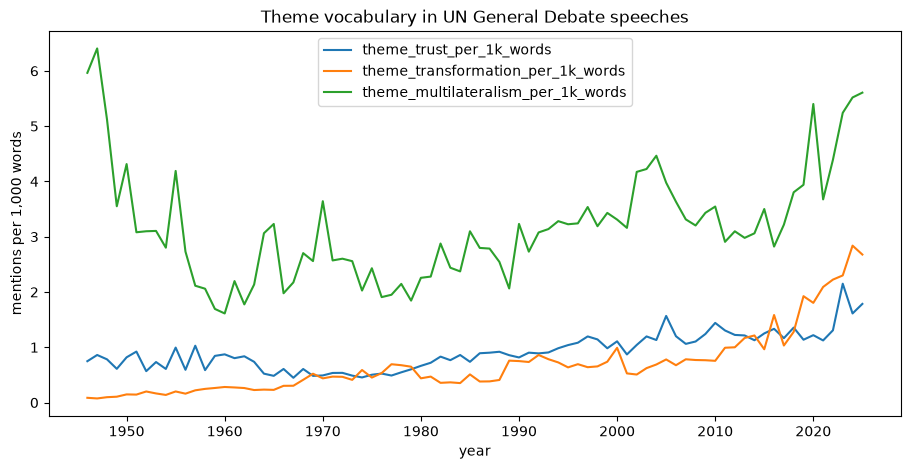

In [8]:
# A first look: how much the themes are talked about over time
yearly = rates.groupby("year")[
    ["theme_trust_per_1k_words", "theme_transformation_per_1k_words",
     "theme_multilateralism_per_1k_words"]
].mean()

yearly.plot(figsize=(11, 5))
plt.ylabel("mentions per 1,000 words")
plt.xlabel("year")
plt.title("Theme vocabulary in UN General Debate speeches")
plt.show()

## Bringing in an external dataset

`merge_country_year` joins on `(country_code, year)` with ISO-3166 alpha-3 codes.
Its defaults match Our World in Data exports (`Entity`, `Code`, `Year`); pass
`country_col` / `year_col` for anything else.

Remember the corpus contains states that no longer exist (`CSK`, `DDR`, `YUG`,
`YMD`) plus `EU`, which external datasets usually lack — expect NaNs there.

In [9]:
# owid = pd.read_csv("../data/external/some-indicator.csv")
# df = merge_country_year(features, owid)
#
# happiness = pd.read_csv("../data/external/happiness.csv")
# df = merge_country_year(features, happiness, country_col="iso3", year_col="year")
#
# print(f"matched {df['<indicator>'].notna().sum():,} of {len(df):,} speeches")

In [12]:
!pip install wordcloud

## Your analysis below

Two reminders from the brief:

- Session 80 (2025) was transcribed from interpretation audio, not official
  transcripts. Be careful reading a 2025 "trend" as real.
- `speaker_role` is `unknown` for many pre-1994 speeches; the UN records do not
  consistently give the speaker's post before then.

In [ ]:
%pip install wordcloud

from wordcloud import WordCloud

last_year = texts["year"].max()
years = list(range(last_year - 29, last_year + 1))

fig, axes = plt.subplots(15, 2, figsize=(14, 45))
axes = axes.ravel()

for ax, year in zip(axes, years):
    tokens = texts.loc[texts["year"].eq(year), "tokens_clean"].dropna()
    text = " ".join(tokens.astype(str))

    if text.strip():
        cloud = WordCloud(
            width=800,
            height=500,
            background_color="white",
            colormap="viridis",
            max_words=100,
        ).generate(text)

        ax.imshow(cloud, interpolation="bilinear")
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")

    ax.set_title(str(year))
    ax.axis("off")

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'wordcloud'